# SPX OpenMC Results Analysis

This notebook reads OpenMC output files from the `SPX_case` run, especially `statepoint.*.h5`, and summarizes:
- `k-effective` and run metadata
- global power-related tally values
- XY/XZ power map tallies
- sampled cell power tallies


## Notes on output files

- `statepoint.*.h5`: main Monte Carlo results (keff, tallies, statistics).
- `summary.h5`: geometry/material summary, used for model metadata.
- `tallies.out`: text dump of tally results.
- `model.xml`, `settings.xml`, etc.: input model used for that run.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmc

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# Use current directory if notebook is opened in SPX_case, otherwise point to SPX_case explicitly.
cwd = Path.cwd()
case_dir = cwd if (cwd / 'SPX').exists() else cwd / 'SPX_case'
if not case_dir.exists():
    raise FileNotFoundError('Could not find SPX_case directory from current working directory.')

statepoints = sorted(case_dir.glob('statepoint.*.h5'))
if not statepoints:
    raise FileNotFoundError(f'No statepoint files found in {case_dir}')

statepoint_path = statepoints[-1]
summary_path = case_dir / 'summary.h5'
print(f'Case directory: {case_dir}')
print(f'Using statepoint: {statepoint_path.name}')
print(f'Summary exists: {summary_path.exists()}')

Case directory: /data/workspace/ACT/ACT-26-02-SERPENT-TO-OPENMC/openmc_serpent_adapter/SPX_case
Using statepoint: statepoint.60.h5
Summary exists: True


In [3]:
sp = openmc.StatePoint(statepoint_path)

print('OpenMC version:', getattr(sp, 'version', 'unknown'))
print('keff:', sp.keff)
print('n_batches:', getattr(sp, 'n_batches', 'n/a'))
print('n_inactive:', getattr(sp, 'n_inactive', 'n/a'))
print('n_particles:', getattr(sp, 'n_particles', 'n/a'))
print('seed:', getattr(sp, 'seed', 'n/a'))
print('run_mode:', getattr(sp, 'run_mode', 'n/a'))
print('tallies in file:', len(sp.tallies))


OpenMC version: (np.int32(0), np.int32(15), np.int32(3))
keff: 1.0314+/-0.0010
n_batches: 60
n_inactive: 15
n_particles: 10000
seed: 1
run_mode: eigenvalue
tallies in file: 9


In [4]:
# List tallies for quick inspection
tally_rows = []
for tally in sp.tallies.values():
    tally_rows.append({
        'id': tally.id,
        'name': tally.name,
        'n_scores': len(tally.scores),
        'scores': ', '.join(str(s) for s in tally.scores),
        'n_filters': len(tally.filters)
    })

tally_df = pd.DataFrame(tally_rows).sort_values('id').reset_index(drop=True)
display(tally_df)


,id,name,n_scores,scores,n_filters
0,1,global_power,2,"kappa-fission, fission",0
1,2,xy_power_map,1,kappa-fission,1
2,3,xz_power_map,1,kappa-fission,1
3,4,cell_power_9,2,"kappa-fission, fission",1
4,5,cell_power_71,2,"kappa-fission, fission",1
5,6,cell_power_163,2,"kappa-fission, fission",1
6,7,cell_power_259,2,"kappa-fission, fission",1
7,8,cell_power_350,2,"kappa-fission, fission",1
8,9,cell_power_402,2,"kappa-fission, fission",1


In [ ]:
# Global power tally

# Some OpenMC/pandas combinations raise in get_pandas_dataframe(); fall back to raw arrays.

global_t = sp.get_tally(name='global_power')


try:

    global_df = global_t.get_pandas_dataframe()

except Exception as exc:

    print('get_pandas_dataframe() failed; using array fallback:', repr(exc))

    score_names = [str(s) for s in global_t.scores]

    means = np.asarray(global_t.mean).reshape(-1)

    stds = np.asarray(global_t.std_dev).reshape(-1)

    global_df = pd.DataFrame({

        'score': score_names,

        'mean': means[:len(score_names)],

        'std_dev': stds[:len(score_names)],

    })


display(global_df)

print('Note: raw tally values are per source normalization in eigenvalue mode.')


get_pandas_dataframe() failed; using array fallback: ValueError('setting an array element with a sequence.')


,score,mean,std_dev
0,kappa-fission,7.095215e+07,92874.921900
1,fission,3.571238e-01,0.000467


Note: raw tally values are per source normalization in eigenvalue mode.


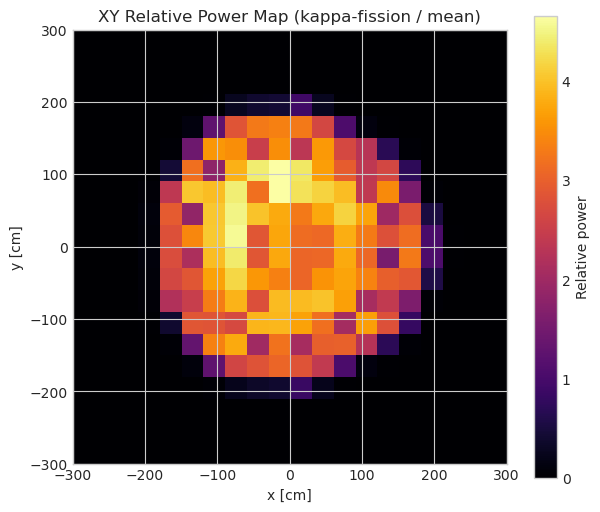

In [6]:
# XY mesh power map
xy_t = sp.get_tally(name='xy_power_map')
xy_mesh_filter = next(f for f in xy_t.filters if isinstance(f, openmc.MeshFilter))
xy_mesh = xy_mesh_filter.mesh
nx, ny, nz = map(int, xy_mesh.dimension)

xy_raw = np.asarray(xy_t.mean).reshape(-1)
xy_cube = xy_raw.reshape((nz, ny, nx))
xy_map = xy_cube[0, :, :]
xy_rel = xy_map / np.mean(xy_map)

ll = np.asarray(xy_mesh.lower_left, dtype=float)
ur = np.asarray(xy_mesh.upper_right, dtype=float)
extent_xy = (ll[0], ur[0], ll[1], ur[1])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(xy_rel, origin='lower', extent=extent_xy, cmap='inferno', aspect='equal')
ax.set_title('XY Relative Power Map (kappa-fission / mean)')
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Relative power')
plt.show()


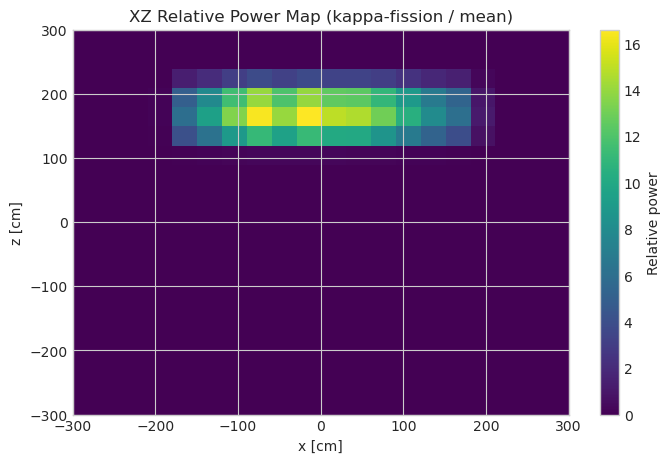

In [7]:
# XZ mesh power map
xz_t = sp.get_tally(name='xz_power_map')
xz_mesh_filter = next(f for f in xz_t.filters if isinstance(f, openmc.MeshFilter))
xz_mesh = xz_mesh_filter.mesh
nx, ny, nz = map(int, xz_mesh.dimension)

xz_raw = np.asarray(xz_t.mean).reshape(-1)
xz_cube = xz_raw.reshape((nz, ny, nx))
xz_map = xz_cube[:, 0, :]
xz_rel = xz_map / np.mean(xz_map)

ll = np.asarray(xz_mesh.lower_left, dtype=float)
ur = np.asarray(xz_mesh.upper_right, dtype=float)
extent_xz = (ll[0], ur[0], ll[2], ur[2])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(xz_rel, origin='lower', extent=extent_xz, cmap='viridis', aspect='auto')
ax.set_title('XZ Relative Power Map (kappa-fission / mean)')
ax.set_xlabel('x [cm]')
ax.set_ylabel('z [cm]')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Relative power')
plt.show()


,tally_id,tally_name,kappa-fission_mean,kappa-fission_std_dev,fission_mean,fission_std_dev
0,4,cell_power_9,4.972916e+04,983.489721,0.000255,0.000005
1,5,cell_power_71,1.643717e+05,2585.324875,0.000835,0.000013
2,6,cell_power_163,2.135427e+04,900.573990,0.000107,0.000005
3,7,cell_power_259,3.354103e+06,25019.755674,0.016875,0.000126
4,8,cell_power_350,2.350724e+04,871.299146,0.000120,0.000004
5,9,cell_power_402,8.566317e+03,525.874362,0.000044,0.000003


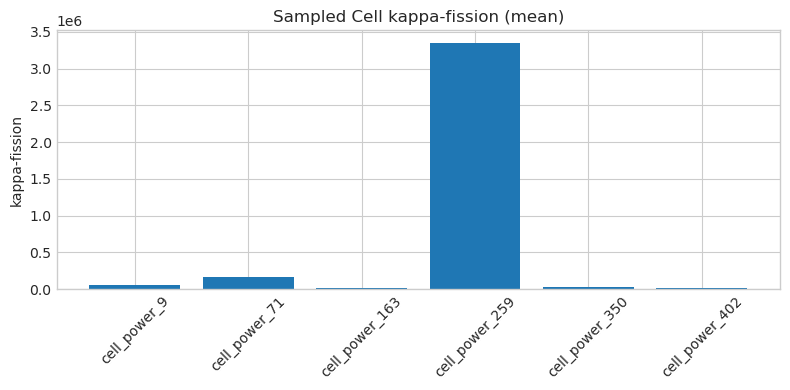

In [8]:
# Cell power tallies summary
cell_tallies = [t for t in sp.tallies.values() if t.name and t.name.startswith('cell_power_')]
rows = []
for t in sorted(cell_tallies, key=lambda tt: tt.id):
    means = np.asarray(t.mean).reshape(-1)
    stds = np.asarray(t.std_dev).reshape(-1)
    score_names = [str(s) for s in t.scores]
    row = {'tally_id': t.id, 'tally_name': t.name}
    for i, sname in enumerate(score_names):
        row[f'{sname}_mean'] = means[i] if i < len(means) else np.nan
        row[f'{sname}_std_dev'] = stds[i] if i < len(stds) else np.nan
    rows.append(row)

cell_df = pd.DataFrame(rows)
display(cell_df)

if 'kappa-fission_mean' in cell_df.columns and not cell_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(cell_df['tally_name'], cell_df['kappa-fission_mean'])
    ax.set_title('Sampled Cell kappa-fission (mean)')
    ax.set_ylabel('kappa-fission')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


In [9]:
# Optional cleanup when done
sp.close()
print('Closed statepoint file.')


Closed statepoint file.
